In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自動抓取並合併所有 GPU 產出的 CSV
all_files = glob.glob("./summary_gpu*.csv")
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

# 2. 將指標欄位轉回浮點數 (float)
metric_cols = ['Final_Sample_CE', 'Final_Theory_CE', 'Final_Sample_KL', 'Final_Theory_KL']
for col in metric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. 移除可能有報錯而產生 NaN 的列，確保資料乾淨
df = df.dropna(subset=metric_cols)

print(f"✅ 成功載入並合併 {len(df)} 組有效實驗數據！")

✅ 成功載入並合併 3024 組有效實驗數據！


In [2]:
# 提取論文最關鍵的核心指標：Theoretical KL (越接近 0 越好)
# 我們看各個「模型架構 x 位置編碼 x 殘差開關」組合下的「最佳(最小) KL 值」

ablation_summary = df.groupby(
    ['Model_Type', 'PE_Type', 'Use_Residual', 'Attention_Only']
)['Final_Theory_KL'].min().unstack('Attention_Only')

# 替換欄位名稱讓表格更直觀
ablation_summary.columns = ['With_FFN (GELU)', 'Attention_Only']
ablation_summary = ablation_summary.sort_values(by='With_FFN (GELU)')

print("🔍 架構消融實驗總表 (數值為該分類下的最佳 Theory KL)：")
display(ablation_summary)

🔍 架構消融實驗總表 (數值為該分類下的最佳 Theory KL)：


With_FFN (GELU)  Attention_Only
Model_Type PE_Type  Use_Residual                                 
linear     rope     False                0.001097        0.015659
standard   rpe      True                 0.003512        0.016235
           absolute False                0.008915        0.017035
           rope     True                 0.014307        0.018419
                    False                0.015420        0.020595
performer  rope     True                 0.017174        0.026282
           absolute True                 0.018804        0.013083
standard   absolute True                 0.019007        0.036188
linear     rope     True                 0.024565        0.031501
performer  absolute False                0.024716        0.023647
standard   rpe      False                0.025013        0.024075
linear     absolute True                 0.025378        0.011150
                    False                0.038364        0.035244
performer  rope     False                0.041189        0.019675

In [3]:
# 找出每個 Data_Name 下，Final_Theory_KL 最低的那一筆實驗配置
best_models_per_dataset = df.loc[df.groupby('Data_Name')['Final_Theory_KL'].idxmin()]

# 挑選關鍵欄位展示
display_cols = ['Data_Name', 'N_Order', 'Model_Type', 'PE_Type', 'LR', 'Final_Theory_KL']
best_summary = best_models_per_dataset[display_cols].sort_values(by=['Data_Name', 'N_Order'])

print("👑 各資料集最佳模型配置：")
display(best_summary)

👑 各資料集最佳模型配置：


,Data_Name,N_Order,Model_Type,PE_Type,LR,Final_Theory_KL
1991,HMM,1,standard,absolute,0.00010,0.008915
257,ICL-Markov,1,standard,rpe,0.00050,0.013041
2799,Markov,1,linear,rope,0.00003,0.001097


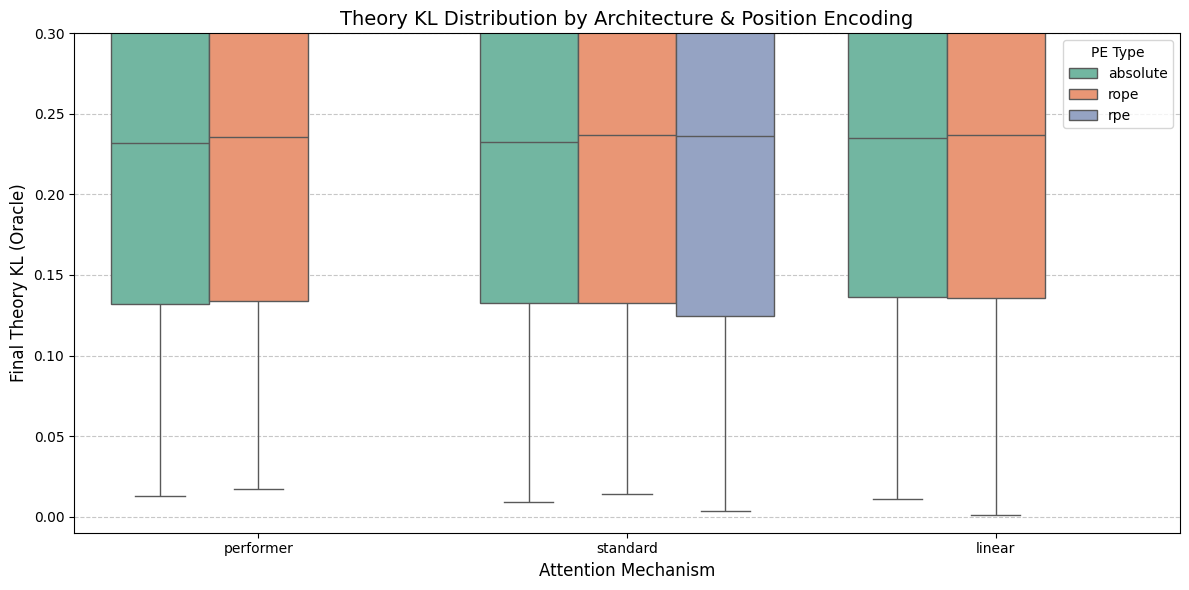

In [4]:
plt.figure(figsize=(12, 6))
# 畫出不同 Model_Type 與 PE_Type 的 KL 分佈
sns.boxplot(
    data=df, 
    x='Model_Type', 
    y='Final_Theory_KL', 
    hue='PE_Type',
    palette='Set2'
)

# 為了看清楚相變點，我們把 Y 軸限制在 0.3 以下 (KL > 0.3 通常代表沒學會)
plt.ylim(-0.01, 0.3)
plt.title("Theory KL Distribution by Architecture & Position Encoding", fontsize=14)
plt.ylabel("Final Theory KL (Oracle)", fontsize=12)
plt.xlabel("Attention Mechanism", fontsize=12)
plt.legend(title='PE Type', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

✅ 成功載入 3024 組實驗數據！


<br><br><hr><h1>📊 賽區：HMM_V3_O1</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,absolute,False,False,0.000100,0.80058,0.80796,0.80058,0.00891
1,1,1,absolute,False,False,0.000100,1.09964,1.09781,1.09964,0.00988
2,2,1,rpe,True,False,0.000500,0.99890,0.99777,0.99890,0.00994
3,2,2,absolute,False,False,0.000100,0.85880,0.86034,0.85880,0.01390
4,2,1,absolute,False,True,0.000030,1.07862,1.07545,1.07862,0.01704
5,1,2,rope,False,True,0.000100,1.11110,1.10572,1.11110,0.02059
6,2,1,rpe,False,False,0.000030,1.03919,1.03228,1.03919,0.02534
7,2,1,rope,True,True,0.000500,1.03975,1.03451,1.03975,0.02778
8,1,1,rpe,True,False,0.000100,0.69467,0.68286,0.69467,0.03003
9,2,1,rpe,False,False,0.000100,1.02095,1.00800,1.02095,0.03125


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rope,True,False,0.000030,0.96140,0.96775,0.96140,0.02457
1,1,1,rope,False,False,0.000500,1.03975,1.04500,1.03975,0.03009
2,1,1,rope,True,True,0.000030,1.04920,1.05239,1.04920,0.03150
3,2,2,absolute,False,True,0.000500,0.78210,0.79469,0.78210,0.03524
4,2,2,rope,False,False,0.000030,1.12071,1.12325,1.12071,0.04483
5,2,1,rope,True,True,0.000500,1.03973,1.03792,1.03973,0.04531
6,2,1,rope,True,True,0.000100,1.09939,1.09992,1.09939,0.05204
7,1,1,rope,False,True,0.000500,1.02635,1.02700,1.02635,0.06041
8,1,1,absolute,False,False,0.000500,1.12844,1.13230,1.12844,0.06524
9,1,1,rope,False,False,0.000100,1.05734,1.05551,1.05734,0.06539


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,rope,False,True,0.000500,1.08016,1.07375,1.08016,0.01968
1,2,2,rope,False,True,0.000500,1.09560,1.09644,1.09560,0.02071
2,2,1,absolute,False,False,0.000500,1.10964,1.11090,1.10964,0.02472
3,2,1,absolute,False,False,0.000100,1.11326,1.11380,1.11326,0.02776
4,2,1,absolute,True,True,0.000500,0.85609,0.85218,0.85609,0.03611
5,1,2,rope,True,False,0.000030,1.02269,1.01974,1.02269,0.04452
6,1,2,rope,True,True,0.000100,1.02607,1.03135,1.02607,0.05571
7,1,1,absolute,False,True,0.000100,1.10481,1.10181,1.10481,0.05854
8,1,1,absolute,True,True,0.000500,0.98125,0.98691,0.98125,0.06071
9,2,2,absolute,False,False,0.000030,0.97162,0.97460,0.97162,0.06877


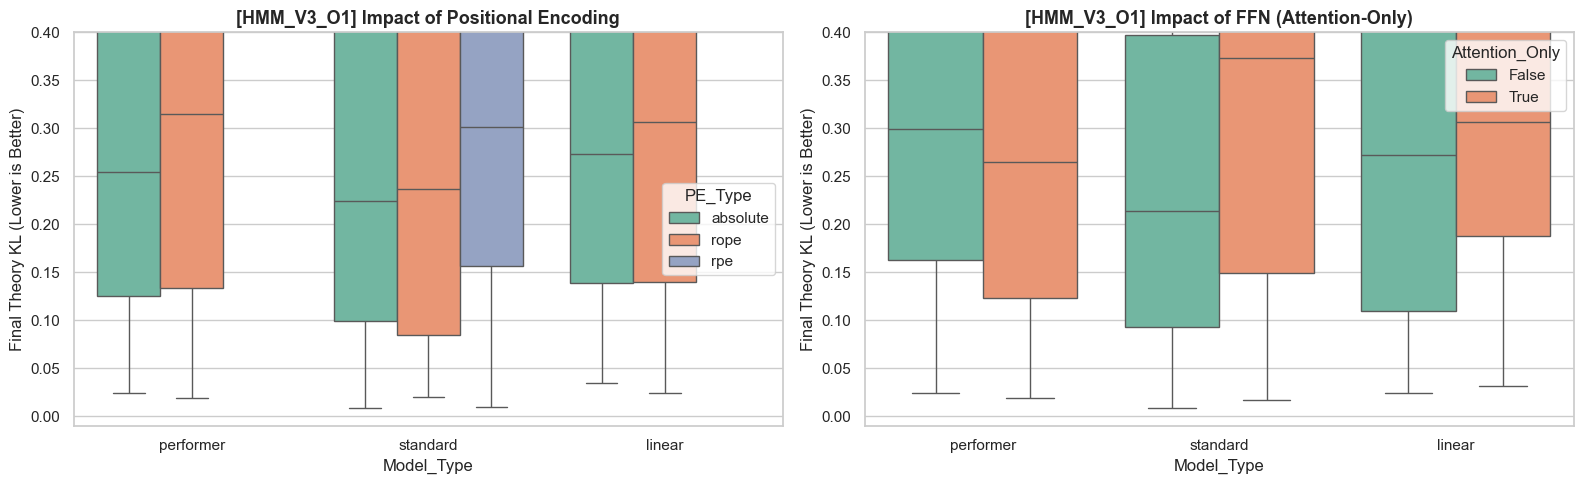

<br><br><hr><h1>📊 賽區：ICL-Markov_V2_O1</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rpe,True,False,0.000500,0.49750,0.49204,0.49750,0.01304
1,2,1,rope,True,False,0.000500,0.48596,0.49339,0.48596,0.01431
2,2,2,rpe,True,True,0.000500,0.50562,0.49801,0.50562,0.01623
3,2,1,rpe,True,False,0.000100,0.50434,0.49368,0.50434,0.01659
4,2,1,rpe,True,False,0.000500,0.49248,0.49722,0.49248,0.01691
5,2,2,rope,True,True,0.000500,0.51797,0.50282,0.51797,0.01842
6,2,1,absolute,True,False,0.000500,0.50214,0.50126,0.50214,0.01901
7,2,2,rope,True,False,0.000500,0.52559,0.50198,0.52559,0.01938
8,2,1,rpe,True,True,0.000500,0.50538,0.49278,0.50538,0.01997
9,2,1,rope,True,True,0.000500,0.50036,0.50349,0.50036,0.02062


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,absolute,True,False,0.000500,0.50727,0.51215,0.50727,0.02538
1,2,2,absolute,True,True,0.000500,0.51163,0.50868,0.51163,0.02913
2,2,2,absolute,False,False,0.000500,0.51252,0.51652,0.51252,0.03836
3,2,2,rope,True,False,0.000500,0.52297,0.51731,0.52297,0.03920
4,2,2,rope,True,True,0.000500,0.52765,0.52632,0.52765,0.04424
5,2,1,absolute,True,True,0.000500,0.53209,0.53215,0.53209,0.05218
6,2,1,absolute,True,False,0.000500,0.53473,0.53289,0.53473,0.05292
7,2,1,rope,True,False,0.000500,0.54644,0.53534,0.54644,0.05344
8,2,2,absolute,False,True,0.000500,0.54224,0.53422,0.54224,0.05506
9,2,2,rope,False,False,0.000500,0.54049,0.53636,0.54049,0.05541


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,absolute,True,False,0.000500,0.51240,0.49790,0.51240,0.01880
1,2,2,absolute,True,False,0.000500,0.50350,0.50105,0.50350,0.02009
2,2,2,absolute,True,True,0.000500,0.49853,0.50376,0.49853,0.02284
3,2,2,absolute,False,False,0.000500,0.51645,0.50359,0.51645,0.02554
4,2,2,rope,True,False,0.000500,0.48980,0.50485,0.48980,0.02591
5,2,2,rope,True,True,0.000500,0.50506,0.50422,0.50506,0.02628
6,2,2,absolute,False,True,0.000500,0.50659,0.51247,0.50659,0.02749
7,2,1,absolute,True,True,0.000500,0.50735,0.51257,0.50735,0.02838
8,2,1,rope,True,False,0.000500,0.52137,0.52349,0.52137,0.03953
9,2,1,rope,True,True,0.000500,0.51772,0.51865,0.51772,0.04061


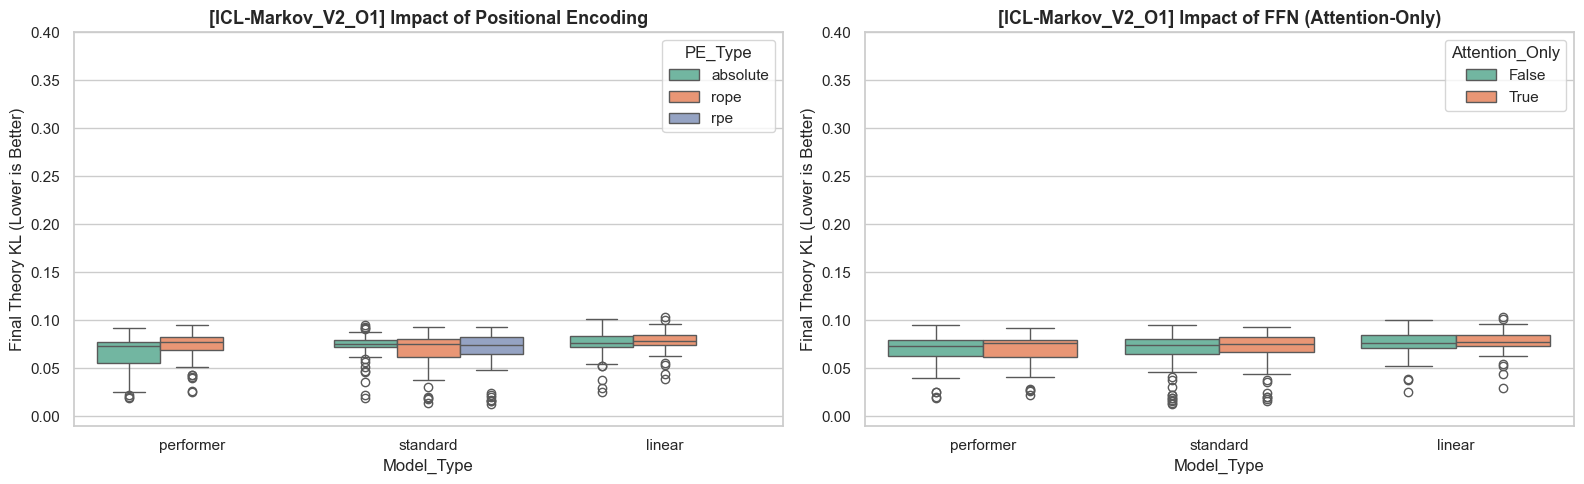

<br><br><hr><h1>📊 賽區：ICL-Markov_V2_O2</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rpe,True,False,0.000500,0.48788,0.49584,0.48788,0.02607
1,2,2,rpe,True,True,0.000500,0.48940,0.49637,0.48940,0.03123
2,2,1,rpe,True,False,0.000500,0.51582,0.50990,0.51582,0.03715
3,2,1,rpe,True,True,0.000500,0.52321,0.53046,0.52321,0.06236
4,2,1,rope,True,False,0.000500,0.53197,0.53806,0.53197,0.06917
5,2,1,absolute,True,False,0.000500,0.55259,0.55521,0.55259,0.08572
6,2,1,rope,True,True,0.000500,0.55592,0.55895,0.55592,0.09218
7,2,2,rope,False,False,0.000500,0.57367,0.57151,0.57367,0.09505
8,2,2,rpe,False,True,0.000500,0.56137,0.56210,0.56137,0.09812
9,2,2,absolute,True,False,0.000500,0.56665,0.57106,0.56665,0.10408


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,absolute,True,False,0.000500,0.57569,0.58060,0.57569,0.11112
1,2,1,absolute,True,False,0.000500,0.58256,0.58532,0.58256,0.11381
2,2,2,absolute,False,True,0.000500,0.58943,0.59091,0.58943,0.11614
3,2,2,absolute,False,False,0.000500,0.56964,0.58307,0.56964,0.11934
4,2,2,rope,True,True,0.000500,0.59680,0.59076,0.59680,0.11944
5,2,2,rope,True,False,0.000500,0.59469,0.59332,0.59469,0.12143
6,2,1,rope,True,False,0.000500,0.59620,0.58949,0.59620,0.12256
7,2,2,rope,False,False,0.000500,0.59427,0.59258,0.59427,0.12547
8,2,1,absolute,False,False,0.000500,0.58411,0.59774,0.58411,0.12646
9,2,2,absolute,True,True,0.000500,0.59999,0.59708,0.59999,0.12673


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,absolute,True,False,0.000500,0.56429,0.56603,0.56429,0.09651
1,2,2,absolute,True,False,0.000500,0.56974,0.56707,0.56974,0.10130
2,2,2,absolute,True,True,0.000500,0.57377,0.56995,0.57377,0.10338
3,2,1,absolute,True,True,0.000500,0.58186,0.57646,0.58186,0.10629
4,2,2,rope,True,False,0.000500,0.57887,0.57556,0.57887,0.10901
5,2,2,rope,True,True,0.000500,0.57859,0.58267,0.57859,0.11010
6,2,2,absolute,False,True,0.000500,0.57691,0.58202,0.57691,0.11166
7,2,1,rope,True,False,0.000500,0.59089,0.58893,0.59089,0.11560
8,2,2,absolute,False,False,0.000500,0.58552,0.58146,0.58552,0.11567
9,2,2,rope,False,True,0.000500,0.57532,0.58279,0.57532,0.11643


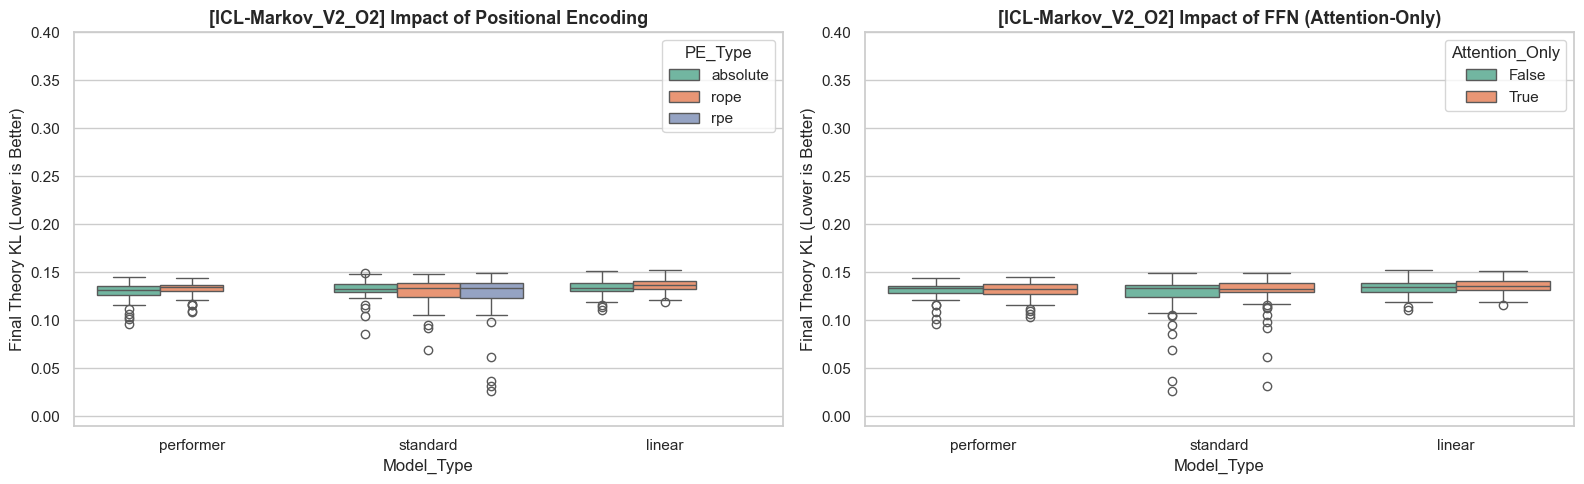

<br><br><hr><h1>📊 賽區：ICL-Markov_V3_O1</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rpe,True,False,0.000500,0.85535,0.85938,0.85535,0.03373
1,2,1,rope,True,False,0.000500,0.85388,0.85093,0.85388,0.03566
2,2,1,rpe,True,False,0.000500,0.85354,0.85170,0.85354,0.03629
3,2,2,rpe,True,True,0.000500,0.86761,0.85800,0.86761,0.03995
4,2,1,rpe,True,True,0.000500,0.88255,0.85925,0.88255,0.04437
5,2,2,rope,True,False,0.000500,0.87281,0.86701,0.87281,0.04501
6,2,2,absolute,True,False,0.000500,0.87868,0.87306,0.87868,0.05046
7,2,1,absolute,True,False,0.000500,0.86230,0.86745,0.86230,0.05096
8,2,1,rpe,True,False,0.000100,0.87345,0.87161,0.87345,0.05264
9,2,2,absolute,True,True,0.000500,0.87630,0.87760,0.87630,0.06127


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,absolute,True,True,0.000500,0.93097,0.93093,0.93097,0.11208
1,2,2,absolute,False,True,0.000500,0.93985,0.93690,0.93985,0.11296
2,2,2,rope,True,True,0.000500,0.94481,0.95382,0.94481,0.13546
3,2,1,absolute,True,False,0.000500,0.95839,0.95761,0.95839,0.13885
4,2,2,rope,True,False,0.000500,0.96635,0.96438,0.96635,0.14260
5,2,2,absolute,True,False,0.000500,0.96998,0.96570,0.96998,0.14527
6,2,2,absolute,False,False,0.000500,0.96364,0.96739,0.96364,0.14836
7,2,1,rope,True,False,0.000500,0.97299,0.97457,0.97299,0.14952
8,2,1,absolute,True,True,0.000500,0.97684,0.97441,0.97684,0.15257
9,2,1,rope,True,True,0.000500,0.98009,0.97588,0.98009,0.15363


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,absolute,True,False,0.000500,0.86182,0.86119,0.86182,0.04200
1,2,2,absolute,True,False,0.000500,0.85552,0.85944,0.85552,0.04319
2,2,1,rope,True,False,0.000500,0.89981,0.88508,0.89981,0.06684
3,2,1,absolute,True,True,0.000500,0.87914,0.88421,0.87914,0.06694
4,2,2,absolute,True,True,0.000500,0.88359,0.89230,0.88359,0.07451
5,2,2,rope,True,False,0.000500,0.90383,0.90264,0.90383,0.08352
6,2,1,rope,True,True,0.000500,0.90803,0.89977,0.90803,0.08408
7,2,2,absolute,False,False,0.000500,0.90405,0.91245,0.90405,0.09127
8,2,2,rope,True,True,0.000500,0.91029,0.91575,0.91029,0.09739
9,2,2,absolute,False,True,0.000500,0.92505,0.93841,0.92505,0.12173


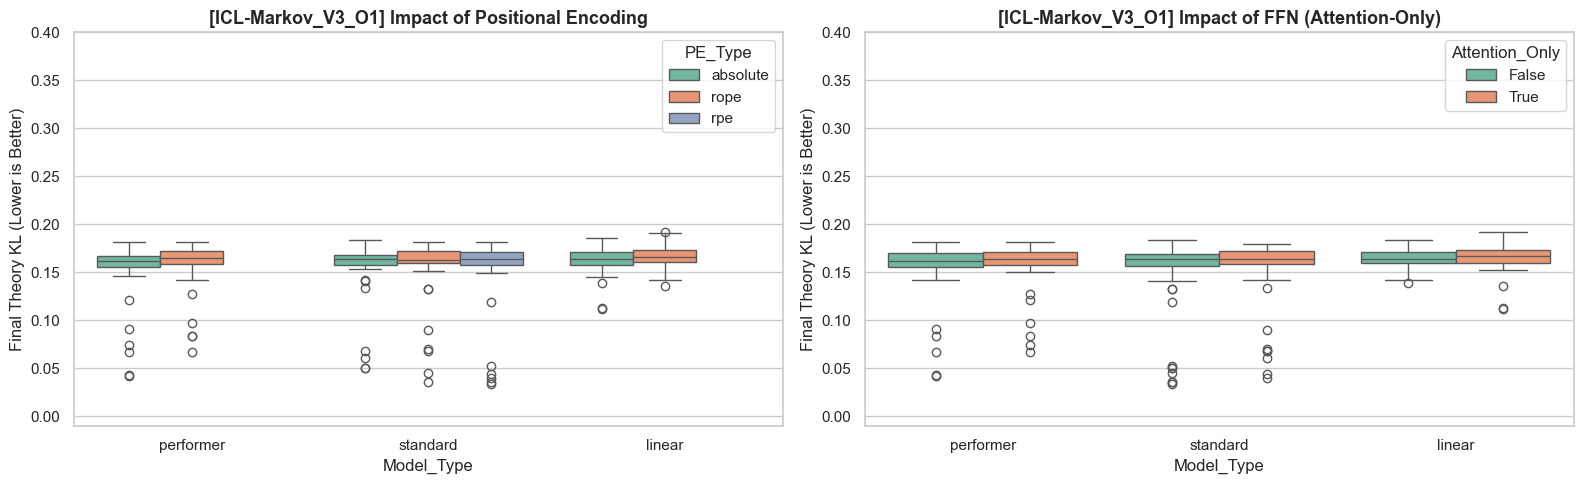

<br><br><hr><h1>📊 賽區：ICL-Markov_V3_O2</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rpe,True,True,0.000500,0.90809,0.89977,0.90809,0.08379
1,2,2,rpe,True,False,0.000500,0.90421,0.90042,0.90421,0.08428
2,2,1,rpe,True,False,0.000500,0.91594,0.91592,0.91594,0.10318
3,2,1,rpe,True,True,0.000500,0.93431,0.94509,0.93431,0.12735
4,2,2,rope,False,False,0.000500,1.01017,1.00850,1.01017,0.19238
5,2,2,rope,True,True,0.000500,1.02251,1.02069,1.02251,0.19776
6,2,2,rope,True,False,0.000500,1.03688,1.02916,1.03688,0.20307
7,2,1,rope,True,False,0.000500,1.02250,1.02115,1.02250,0.20332
8,2,2,rpe,False,True,0.000500,1.02776,1.02291,1.02776,0.20474
9,2,1,absolute,True,False,0.000500,1.01962,1.01971,1.01962,0.20487


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,absolute,True,True,0.000100,1.04519,1.05144,1.04519,0.22901
1,2,1,absolute,True,True,0.000100,1.04635,1.05018,1.04635,0.23005
2,2,1,absolute,False,False,0.000500,1.05191,1.05303,1.05191,0.23084
3,2,2,rope,True,True,0.000500,1.04655,1.05071,1.04655,0.23117
4,2,1,absolute,True,False,0.000500,1.05022,1.05209,1.05022,0.23136
5,2,2,absolute,True,False,0.000100,1.05503,1.05762,1.05503,0.23233
6,1,2,absolute,True,False,0.000500,1.05700,1.05621,1.05700,0.23241
7,2,2,rope,True,False,0.000500,1.05922,1.05435,1.05922,0.23306
8,1,1,absolute,True,True,0.000500,1.05451,1.05603,1.05451,0.23359
9,1,1,rope,True,True,0.000100,1.05583,1.05419,1.05583,0.23374


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,rope,True,False,0.000500,1.02217,1.02125,1.02217,0.20570
1,2,2,absolute,True,False,0.000500,1.03764,1.03566,1.03764,0.21656
2,2,1,absolute,True,False,0.000500,1.03345,1.03364,1.03345,0.21730
3,2,1,absolute,True,True,0.000500,1.02879,1.03325,1.02879,0.21783
4,2,2,absolute,True,True,0.000500,1.04992,1.04931,1.04992,0.22485
5,2,1,absolute,False,True,0.000500,1.05398,1.05063,1.05398,0.22677
6,2,1,rope,True,True,0.000500,1.04530,1.04714,1.04530,0.22844
7,2,2,rope,True,False,0.000500,1.05221,1.05141,1.05221,0.22923
8,2,2,rope,True,True,0.000500,1.04418,1.04781,1.04418,0.23079
9,1,1,absolute,False,False,0.000100,1.04910,1.05056,1.04910,0.23087


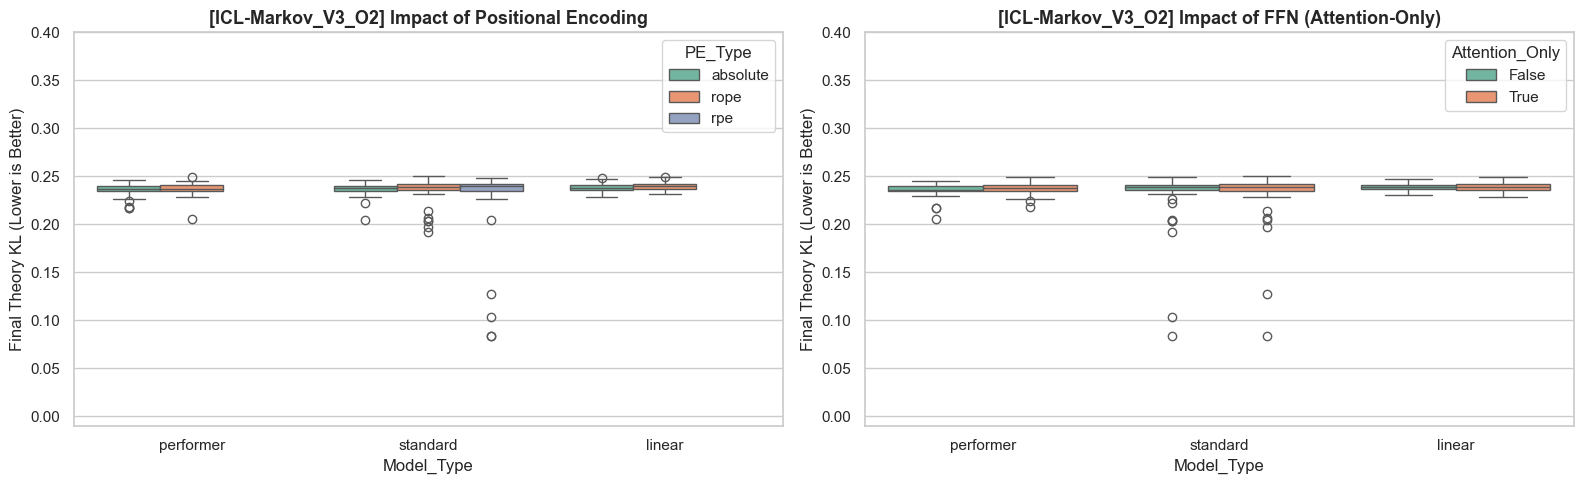

<br><br><hr><h1>📊 賽區：Markov_V2_O1</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,rpe,True,False,0.000030,0.25084,0.23716,0.25084,0.00351
1,1,2,absolute,False,False,0.000500,0.57601,0.57106,0.57601,0.01457
2,1,2,rope,False,False,0.000500,0.64685,0.64889,0.64685,0.01542
3,2,2,rpe,False,False,0.000100,0.38705,0.38328,0.38705,0.02501
4,2,1,rope,False,True,0.000030,0.56998,0.56301,0.56998,0.02753
5,2,2,absolute,True,False,0.000030,0.68061,0.67963,0.68061,0.02917
6,2,2,rope,True,False,0.000100,0.24262,0.23708,0.24262,0.03055
7,1,1,rpe,False,False,0.000500,0.17451,0.18040,0.17451,0.03578
8,1,2,rpe,False,True,0.000500,0.52598,0.52228,0.52598,0.04382
9,2,2,absolute,False,False,0.000500,0.22071,0.21763,0.22071,0.04434


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,rope,False,False,0.000030,0.17946,0.17845,0.17946,0.00110
1,2,1,rope,False,False,0.000030,0.03209,0.02997,0.03209,0.00558
2,2,1,absolute,True,True,0.000100,0.17831,0.18812,0.17831,0.01115
3,2,2,rope,False,True,0.000030,0.57495,0.57900,0.57495,0.01566
4,1,1,absolute,True,True,0.000030,0.56773,0.56175,0.56773,0.02276
5,2,2,rope,False,False,0.000500,0.55196,0.55836,0.55196,0.02557
6,2,2,absolute,True,True,0.000030,0.29757,0.31653,0.29757,0.02996
7,2,1,rope,False,False,0.000100,0.72933,0.73094,0.72933,0.04267
8,1,1,rope,False,True,0.000500,0.50315,0.51289,0.50315,0.04507
9,2,1,absolute,False,False,0.000100,0.61151,0.60258,0.61151,0.04857


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,absolute,True,True,0.000500,0.66155,0.66237,0.66155,0.01308
1,2,1,rope,True,False,0.000030,0.19971,0.20103,0.19971,0.01717
2,1,1,absolute,True,False,0.000100,0.68763,0.68780,0.68763,0.02200
3,1,1,absolute,False,True,0.000500,0.59768,0.61242,0.59768,0.04015
4,1,1,rope,False,False,0.000100,0.50365,0.50522,0.50365,0.04119
5,2,2,rope,True,True,0.000500,0.60104,0.60932,0.60104,0.04190
6,1,1,rope,False,True,0.000030,0.73303,0.73718,0.73303,0.04492
7,2,2,rope,False,False,0.000100,0.65864,0.65333,0.65864,0.05066
8,1,1,rope,False,True,0.000100,0.52729,0.51167,0.52729,0.05710
9,1,2,absolute,False,False,0.000100,0.69103,0.69149,0.69103,0.05763


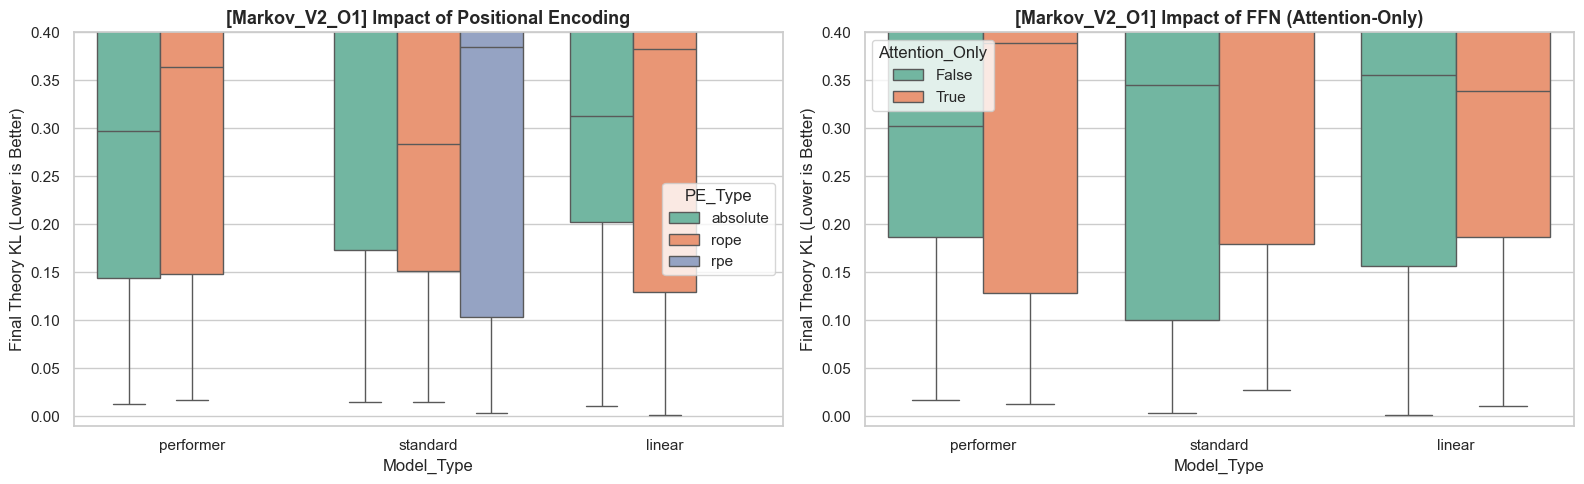

<br><br><hr><h1>📊 賽區：Markov_V2_O2</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,rpe,False,False,0.000500,0.57005,0.57445,0.57005,0.03124
1,2,1,rpe,True,True,0.000100,0.64704,0.64369,0.64704,0.04009
2,2,1,rope,False,True,0.000100,0.66302,0.65563,0.66302,0.04095
3,1,1,rpe,False,False,0.000100,0.67028,0.67270,0.67028,0.04105
4,1,2,rpe,True,True,0.000500,0.52588,0.51918,0.52588,0.04452
5,1,2,rope,True,False,0.000030,0.69275,0.69371,0.69275,0.04648
6,2,2,absolute,True,False,0.000100,0.70457,0.70331,0.70457,0.06564
7,1,1,absolute,False,False,0.000100,0.62816,0.59866,0.62816,0.06790
8,2,2,rpe,True,True,0.000100,0.73051,0.74453,0.73051,0.08667
9,1,2,rope,False,False,0.000500,0.69327,0.69737,0.69327,0.08777


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,1,rope,True,True,0.000100,0.53002,0.53633,0.53002,0.05518
1,2,2,absolute,False,True,0.000030,0.57701,0.57649,0.57701,0.05746
2,2,1,rope,False,True,0.000100,0.66807,0.66592,0.66807,0.06214
3,1,1,rope,False,False,0.000030,0.69942,0.69690,0.69942,0.07017
4,1,1,rope,False,False,0.000500,0.58455,0.58603,0.58455,0.07091
5,2,2,absolute,True,True,0.000030,0.71792,0.71498,0.71792,0.07562
6,1,2,absolute,True,False,0.000100,0.67537,0.66878,0.67537,0.07727
7,2,1,rope,False,False,0.000100,0.66564,0.66280,0.66564,0.07764
8,2,2,rope,True,True,0.000030,0.57627,0.57573,0.57627,0.07837
9,2,2,rope,False,True,0.000500,0.62468,0.62185,0.62468,0.08170


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,1,absolute,False,True,0.000100,0.60697,0.60088,0.60697,0.02365
1,2,1,rope,True,True,0.000030,0.55465,0.55783,0.55465,0.04474
2,1,1,rope,False,True,0.000500,0.66430,0.66360,0.66430,0.04671
3,2,1,rope,False,False,0.000030,0.72224,0.72115,0.72224,0.08755
4,2,2,absolute,False,True,0.000030,0.61448,0.60607,0.61448,0.09358
5,1,1,rope,False,True,0.000030,0.69134,0.69188,0.69134,0.10176
6,1,2,rope,False,False,0.000500,0.66905,0.66700,0.66905,0.11863
7,1,1,rope,False,False,0.000030,0.59403,0.60289,0.59403,0.12483
8,2,1,rope,True,True,0.000100,0.66231,0.65920,0.66231,0.12595
9,2,1,absolute,False,False,0.000030,0.49875,0.49456,0.49875,0.14156


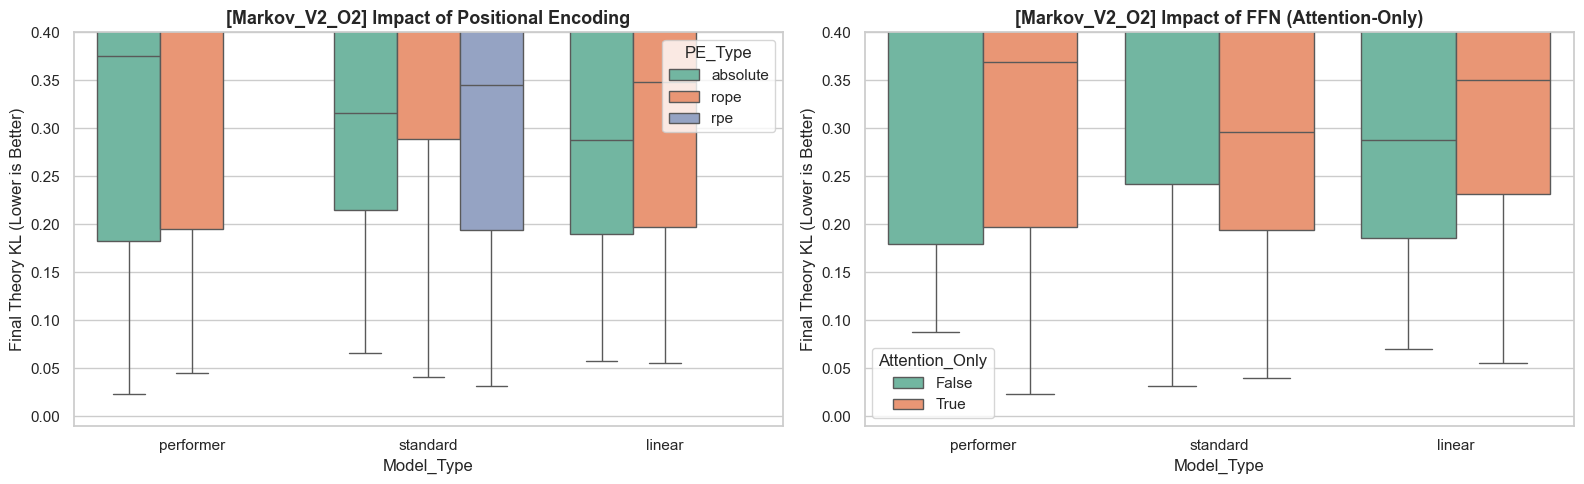

<br><br><hr><h1>📊 賽區：Markov_V3_O1</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,absolute,True,False,0.000500,1.04221,1.04864,1.04221,0.07774
1,1,1,rpe,True,False,0.000500,0.97599,0.97462,0.97599,0.09661
2,2,2,rpe,True,True,0.000500,0.98895,1.00654,0.98895,0.10438
3,1,1,rpe,False,True,0.000500,1.01504,1.00790,1.01504,0.11335
4,1,1,absolute,True,True,0.000100,0.95109,0.93853,0.95109,0.12237
5,2,2,rope,False,False,0.000500,0.99067,1.00379,0.99067,0.17398
6,1,1,absolute,False,False,0.000500,0.98305,0.99536,0.98305,0.17466
7,2,1,absolute,True,True,0.000100,1.12869,1.10928,1.12869,0.17990
8,1,2,absolute,True,False,0.000030,0.96986,0.97638,0.96986,0.19996
9,2,2,rpe,False,True,0.000500,1.04925,1.04143,1.04925,0.20811


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,2,rope,False,True,0.000500,1.09705,1.09681,1.09705,0.07018
1,1,1,rope,False,False,0.000030,0.87867,0.87177,0.87867,0.07612
2,1,1,absolute,True,True,0.000030,1.01904,1.02242,1.01904,0.08361
3,1,2,absolute,False,False,0.000500,0.89938,0.90426,0.89938,0.09685
4,1,2,rope,True,False,0.000500,1.01767,1.00426,1.01767,0.13156
5,2,2,absolute,False,True,0.000030,1.07989,1.08057,1.07989,0.14120
6,2,2,rope,True,True,0.000100,1.17338,1.16903,1.17338,0.14718
7,1,2,absolute,False,False,0.000030,0.55211,0.55160,0.55211,0.16895
8,1,2,rope,False,True,0.000500,1.05432,1.05578,1.05432,0.19743
9,2,1,absolute,True,True,0.000500,1.10579,1.10892,1.10579,0.20684


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,rope,True,True,0.000100,0.77491,0.79476,0.77491,0.07862
1,2,2,rope,False,True,0.000030,1.06934,1.05495,1.06934,0.08311
2,1,2,absolute,True,False,0.000100,0.93240,0.91936,0.93240,0.08528
3,2,1,absolute,False,False,0.000500,0.81002,0.79250,0.81002,0.08649
4,2,2,rope,False,True,0.000500,0.93759,0.94540,0.93759,0.13874
5,1,1,rope,False,True,0.000030,0.98345,0.99338,0.98345,0.18175
6,2,1,absolute,False,True,0.000100,1.19632,1.19660,1.19632,0.18277
7,1,2,rope,True,True,0.000100,0.92319,0.91051,0.92319,0.19004
8,2,1,rope,False,True,0.000030,1.10866,1.10913,1.10866,0.21962
9,2,1,absolute,False,True,0.000030,1.22033,1.23565,1.22033,0.24991


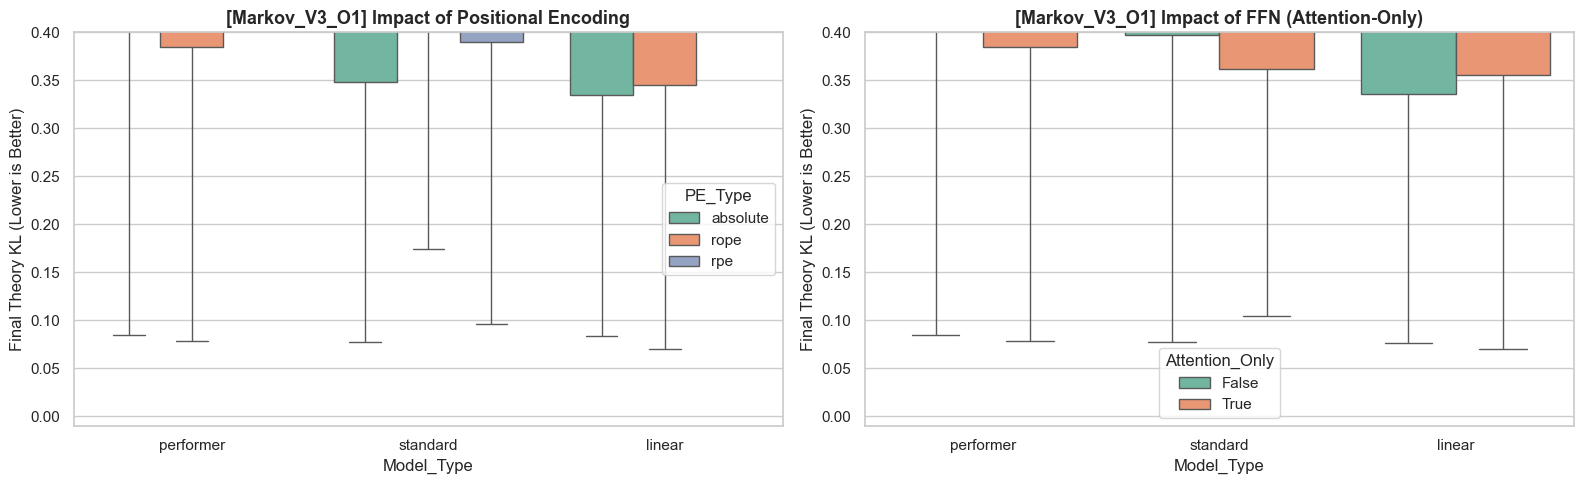

<br><br><hr><h1>📊 賽區：Markov_V3_O2</h1>

*(本賽區共有 336 組模型配置參與對比)*

### 🤖 門派：`STANDARD` (共 144 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,rpe,False,True,0.000100,0.93975,0.94606,0.93975,0.15248
1,1,2,absolute,True,True,0.000100,1.12744,1.13102,1.12744,0.16909
2,2,2,rope,True,False,0.000030,1.08651,1.07883,1.08651,0.21353
3,1,2,absolute,False,False,0.000100,1.13055,1.13216,1.13055,0.22279
4,2,2,absolute,False,True,0.000030,1.12646,1.12005,1.12646,0.22772
5,2,2,rope,False,False,0.000100,1.20742,1.19871,1.20742,0.23047
6,2,2,absolute,True,True,0.000100,1.07107,1.07065,1.07107,0.23218
7,1,1,rope,True,False,0.000030,1.14148,1.13982,1.14148,0.25836
8,2,1,rope,True,False,0.000030,1.16618,1.15867,1.16618,0.25916
9,1,1,rpe,True,True,0.000030,1.13072,1.13516,1.13072,0.26043


### 🤖 門派：`LINEAR` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,2,1,rope,False,True,0.000500,1.06906,1.06068,1.06906,0.18179
1,2,1,absolute,True,False,0.000030,1.11246,1.10486,1.11246,0.20236
2,1,2,absolute,False,True,0.000500,1.13398,1.13460,1.13398,0.20836
3,2,1,rope,False,True,0.000100,1.07273,1.07544,1.07273,0.20913
4,1,1,rope,True,True,0.000030,1.15965,1.15593,1.15965,0.21492
5,2,2,absolute,False,True,0.000500,1.02409,1.01458,1.02409,0.21591
6,2,2,absolute,True,True,0.000030,1.23087,1.20993,1.23087,0.21780
7,1,2,rope,False,True,0.000500,1.00131,1.00490,1.00131,0.22129
8,1,1,absolute,False,False,0.000030,1.10032,1.10429,1.10032,0.22319
9,1,1,rope,False,False,0.000100,1.04607,1.04785,1.04607,0.23070


### 🤖 門派：`PERFORMER` (共 96 組)

,Layers,Heads,PE_Type,Use_Residual,Attention_Only,LR,Final_Sample_CE,Final_Theory_CE,Final_Sample_KL,Final_Theory_KL
0,1,2,rope,False,False,0.000100,1.07139,1.06987,1.07139,0.11717
1,1,2,absolute,True,False,0.000500,1.15010,1.14578,1.15010,0.16326
2,1,2,absolute,True,True,0.000100,1.01933,1.01620,1.01933,0.16700
3,1,1,rope,True,True,0.000030,1.08301,1.08810,1.08301,0.17093
4,1,2,absolute,False,False,0.000100,1.14139,1.13197,1.14139,0.18108
5,1,1,absolute,True,True,0.000030,1.10310,1.10092,1.10310,0.19582
6,1,2,absolute,False,False,0.000030,1.12819,1.12085,1.12819,0.22646
7,1,1,absolute,False,True,0.000030,1.10128,1.10154,1.10128,0.23025
8,1,1,rope,False,False,0.000030,1.14149,1.14895,1.14149,0.23363
9,2,1,rope,True,False,0.000030,1.05687,1.03926,1.05687,0.24062


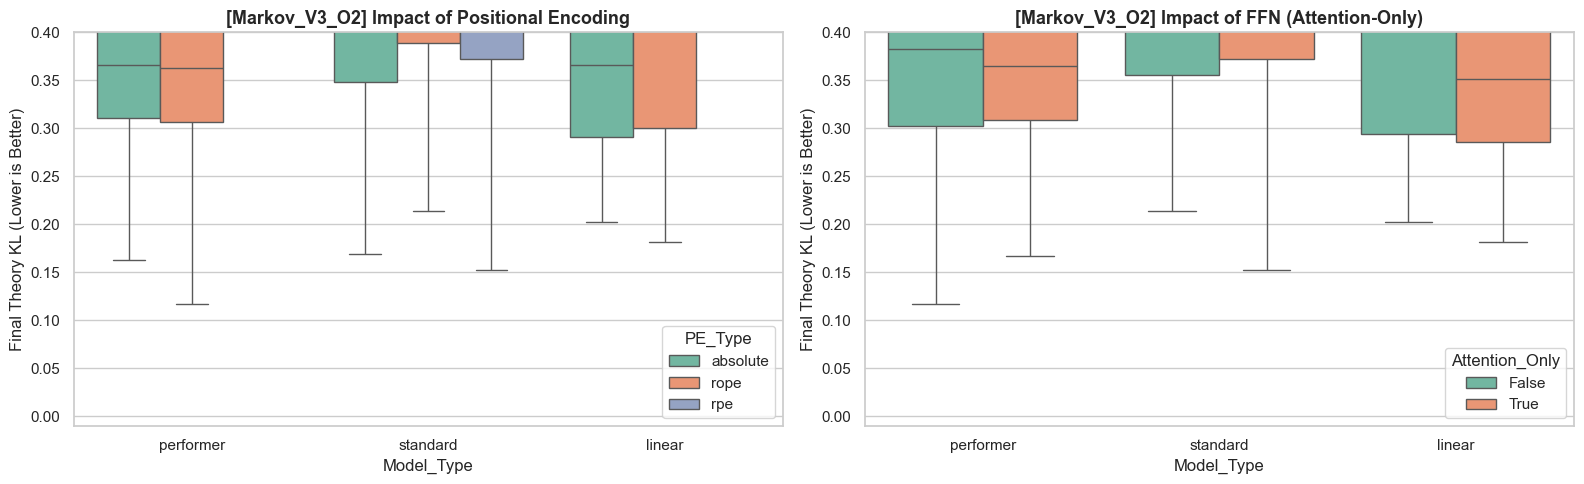

In [11]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ==========================================
# 1. 載入與清理實驗資料
# ==========================================
def load_and_clean_data(filepath_pattern="./summary_gpu*.csv"):
    all_files = glob.glob(filepath_pattern)
    if not all_files:
        print("❌ 找不到 CSV 檔案，請確認你所在的目錄是否有 'results/' 資料夾！")
        return None
        
    df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    
    # 確保所有評估指標都是乾淨的浮點數
    metric_cols = ['Final_Sample_CE', 'Final_Theory_CE', 'Final_Sample_KL', 'Final_Theory_KL']
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df.dropna(subset=metric_cols)
    print(f"✅ 成功載入 {len(df)} 組實驗數據！")
    return df

# ==========================================
# 2. 全覽分區檢視分析函數 (四指標全開版)
# ==========================================
def analyze_single_dataset_full_grouped(df, dataset_name):
    ds_df = df[df['Dataset_Setting'] == dataset_name].copy()
    
    display(Markdown(f"<br><br><hr><h1>📊 賽區：{dataset_name}</h1>"))
    display(Markdown(f"*(本賽區共有 {len(ds_df)} 組模型配置參與對比)*"))
    
    # 🌟 修改點 1：將四個核心指標全部加入顯示清單
    display_cols = [
        'Layers', 'Heads', 'PE_Type', 'Use_Residual', 'Attention_Only', 'LR', 
        'Final_Sample_CE', 'Final_Theory_CE', 'Final_Sample_KL', 'Final_Theory_KL'
    ]
    
    # 🌟 修改點 2：針對四個指標統一做小數點格式化設定
    format_dict = {
        'Final_Sample_CE': "{:.5f}",
        'Final_Theory_CE': "{:.5f}",
        'Final_Sample_KL': "{:.5f}",
        'Final_Theory_KL': "{:.5f}"
    }
    
    # --- A. 門派分流排行榜 ---
    for model_type in ['standard', 'linear', 'performer']:
        # 篩選該門派，依然依照 Theory KL 作為最重要的排序依據
        model_df = ds_df[ds_df['Model_Type'] == model_type].sort_values(by='Final_Theory_KL')
        
        if model_df.empty:
            continue
            
        display(Markdown(f"### 🤖 門派：`{model_type.upper()}` (共 {len(model_df)} 組)"))
        
        # 加上 display.max_columns 確保欄位變多時不會被折疊
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            # 漸層視覺依然保留在最關鍵的 Final_Theory_KL 上，方便一眼看出收斂斷層
            styled_table = model_df[display_cols].reset_index(drop=True).style.background_gradient(
                cmap='Blues_r', subset=['Final_Theory_KL']
            ).format(format_dict)
            
            display(styled_table)
    
    # --- B. 視覺化：架構消融對比圖 ---
    sns.set_theme(style="whitegrid", palette="Set2")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.boxplot(
        data=ds_df, x='Model_Type', y='Final_Theory_KL', hue='PE_Type', ax=axes[0]
    )
    axes[0].set_title(f"[{dataset_name}] Impact of Positional Encoding", fontsize=13, fontweight='bold')
    axes[0].set_ylabel("Final Theory KL (Lower is Better)")
    axes[0].set_ylim(-0.01, 0.4) 
    
    sns.boxplot(
        data=ds_df, x='Model_Type', y='Final_Theory_KL', hue='Attention_Only', ax=axes[1]
    )
    axes[1].set_title(f"[{dataset_name}] Impact of FFN (Attention-Only)", fontsize=13, fontweight='bold')
    axes[1].set_ylabel("Final Theory KL (Lower is Better)")
    axes[1].set_ylim(-0.01, 0.4)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 主執行區塊
# ==========================================
df_results = load_and_clean_data()

if df_results is not None:
    unique_datasets = sorted(df_results['Dataset_Setting'].unique())
    for ds_name in unique_datasets:
        analyze_single_dataset_full_grouped(df_results, ds_name)

In [12]:
import pandas as pd
import glob
import os

# ==========================================
# 1. 載入與清理資料
# ==========================================
all_files = glob.glob("results/summary_gpu*.csv")
if not all_files:
    print("❌ 找不到 CSV 檔案，請確認你所在的目錄是否有 'results/' 資料夾！")
else:
    df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    
    # 確保指標欄位皆為浮點數
    metric_cols = ['Final_Sample_CE', 'Final_Theory_CE', 'Final_Sample_KL', 'Final_Theory_KL']
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df.dropna(subset=metric_cols)
    
    # 建立專屬的匯出資料夾
    export_dir = "google_sheet_exports"
    os.makedirs(export_dir, exist_ok=True)
    
    # 定義要匯出的精華欄位
    export_cols = [
        'Dataset_Setting', 'Model_Type', 'Layers', 'Heads', 'PE_Type', 
        'Use_Residual', 'Attention_Only', 'LR', 
        'Final_Sample_CE', 'Final_Theory_CE', 'Final_Sample_KL', 'Final_Theory_KL'
    ]
    
    # ==========================================
    # 2. 預先排序與四捨五入處理
    # ==========================================
    # 直接依照 賽區 -> 門派 -> 理論KL (越低越好) 排序
    df_sorted = df.sort_values(
        by=['Dataset_Setting', 'Model_Type', 'Final_Theory_KL'],
        ascending=[True, True, True]
    )[export_cols]
    
    # 將小數點統一格式化為 5 位，讓 Google Sheet 讀取時整齊劃一
    for col in metric_cols:
        df_sorted[col] = df_sorted[col].round(5)
    
    # ==========================================
    # 3. 執行匯出
    # ==========================================
    # 方法一：匯出單一總表 (適合在 Google Sheet 建立母表，利用「建立篩選器」來看)
    master_path = os.path.join(export_dir, "All_Results_Master.csv")
    df_sorted.to_csv(master_path, index=False)
    print(f"✅ [母表匯出成功] 總表已儲存至：{master_path}")
    
    # 方法二：依據資料集拆分匯出 (適合每個實驗建立一個獨立的工作表分頁)
    unique_datasets = df_sorted['Dataset_Setting'].unique()
    for ds_name in unique_datasets:
        ds_df = df_sorted[df_sorted['Dataset_Setting'] == ds_name]
        
        # 過濾掉可能造成檔名錯誤的斜線字元
        safe_name = ds_name.replace("/", "_")
        out_path = os.path.join(export_dir, f"{safe_name}_Rankings.csv")
        
        # 存檔時拿掉 Dataset_Setting 欄位，因為檔名已經說明了
        ds_df.drop(columns=['Dataset_Setting']).to_csv(out_path, index=False)
        print(f"📄 [子表匯出成功] {safe_name} 已儲存至：{out_path}")
        
    print("\n🎉 全部匯出完成！你可以去 'google_sheet_exports' 資料夾把檔案拖進 Google Drive 了。")

❌ 找不到 CSV 檔案，請確認你所在的目錄是否有 'results/' 資料夾！
